#### We will do the following steps in order:

Load and normalize the CIFAR10 training and test datasets using torchvision

Define a Convolutional Neural Network

Define a loss function

Train the network on the training data

Test the network on the test data

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.transforms import v2
import torchvision

In [2]:
Image_preprocess = v2.Compose([
    v2.ToImage(),    # Converts image to a pytorch object, behaves like a tensor
    v2.ToDtype(torch.float32, scale = True),  # Converts from uint8 to float32 and scaling divides image pixels by 255
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# The RGB Images in CIFAR have the form: "(mean_R, mean_G, mean_B)
# (std_R, std_G, std_B)"

# for normalisation, we provide mean & std as 0.5, so pixel values get a range of [-1,1], 0 → -1, 0.5 → 0,1 → +1, according to the z-score formula

batch = 5

training_data = torchvision.datasets.CIFAR10(root = './data', train=True, download = True, transform = Image_preprocess)
training_loader = torch.utils.data.DataLoader(training_data, batch_size = batch, shuffle = True, num_workers=6)          # Always shuffle training data, so that model sees variety, otherwise training can be slow on fixed Data
test_data = torchvision.datasets.CIFAR10(root = './data', train=False, download = True, transform = Image_preprocess)        # "./data" is the relative path, which gets set up in the current directory, "./.data" sets up a hidden folder, on macos/linux machine starting with a "." means it is hidden
test_loader = torch.utils.data.DataLoader(test_data, batch_size = batch, shuffle = True, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
import os

print(os.cpu_count())

16


In [4]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

torch.Size([3, 36, 172])


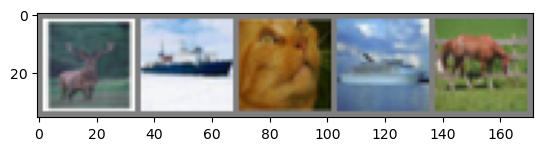

 deer  ship   cat  ship horse


In [5]:
import matplotlib.pyplot as plt                      
import numpy as np

# The Images are stored in the form of normalized tensors of shape (3, 32, 32)

def imgshow(img):
    img = img / 2 + 0.5     # unnormalization
    print(img.shape)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

iterable = iter(training_loader)
images, labels = next(iterable)
imgshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(batch)))    # "%5s %" forces a string to occupy 5 character space by leading with empty spaces

In [6]:
class Net(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        c1 = F.relu(self.conv1(input))
        s2 = F.max_pool2d(c1, (2, 2))
        c3 = F.relu(self.conv2(s2))
        s4 = F.max_pool2d(c3, 2)
        s4 = torch.flatten(s4, 1)
        f5 = F.relu(self.fc1(s4))
        f6 = F.relu(self.fc2(f5))
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [7]:
optimizer = optim.SGD(net.parameters(), lr = 0.005, momentum = 0.9)
criterion = nn.CrossEntropyLoss()

## Training.....!!!

In [8]:
for epoch in range(5):
    running_loss = 0.0
    for index, data in enumerate(training_loader,0):
        img_ten,label_ten = data
        optimizer.zero_grad()
        output_forward = net(img_ten)
        loss_func = criterion(output_forward, target = label_ten)
        loss_func.backward()
        optimizer.step()
        running_loss = running_loss + loss_func.item()
        if index % 2000 == 1999:            # every 2000 batches
            print(f'[{epoch + 1}, {index + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
print("Training Completed")

[1,  2000] loss: 2.006
[1,  4000] loss: 1.697
[1,  6000] loss: 1.629
[1,  8000] loss: 1.569
[1, 10000] loss: 1.523
[2,  2000] loss: 1.492
[2,  4000] loss: 1.501
[2,  6000] loss: 1.489
[2,  8000] loss: 1.492
[2, 10000] loss: 1.465
[3,  2000] loss: 1.437
[3,  4000] loss: 1.436
[3,  6000] loss: 1.457
[3,  8000] loss: 1.436
[3, 10000] loss: 1.454
[4,  2000] loss: 1.401
[4,  4000] loss: 1.453
[4,  6000] loss: 1.407
[4,  8000] loss: 1.422
[4, 10000] loss: 1.442
[5,  2000] loss: 1.386
[5,  4000] loss: 1.415
[5,  6000] loss: 1.422
[5,  8000] loss: 1.446
[5, 10000] loss: 1.457
Training Completed


In [9]:
path = './cifar_model.pt'
torch.save(net.state_dict(), path)

## Testing

torch.Size([3, 36, 172])


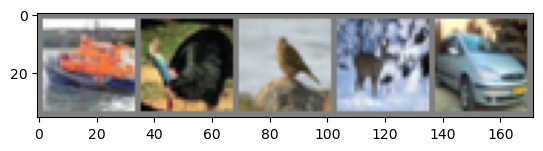

Real labels:   ship  bird  bird  deer   car


In [10]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
imgshow(torchvision.utils.make_grid(images))
print('Real labels: ', ' '.join('%5s' % classes[labels[j]] for j in range(batch)))

In [11]:
# loading model
net = Net()
net.load_state_dict(torch.load(path, weights_only=True))

<All keys matched successfully>

In [12]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted labels: ', ' '.join('%5s' % classes[predicted[j]] for j in range(batch)))

Predicted labels:   ship   cat plane   cat   car


In [13]:
correct = 0
total = 0
with torch.no_grad():
    img,lbl = data
    outputs = net(img)
    _, predicted = torch.max(outputs.data, 1)     # torch.max(output, dimension) returns (value, index)
    total += lbl.size(0)
    correct += (predicted == lbl).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 40 %


In [14]:
print(_)

tensor([3.0383, 2.0882, 3.2167, 1.3817, 1.9441])


In [15]:
correct_pred = {class_name: 0 for class_name in classes}
total_pred = {class_name: 0 for class_name in classes}

with torch.no_grad():
    for data in test_loader:
        imge,labl = data
        outputs = net(imge)
        _, predicted = torch.max(outputs, 1)
        for labl, prediction in zip(labl, predicted):
            if labl == prediction:
                correct_pred[classes[labl]] += 1
            total_pred[classes[labl]] += 1

for class_name, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[class_name]
    print(f'Accuracy for class: {class_name:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 24.3 %
Accuracy for class: car   is 75.8 %
Accuracy for class: bird  is 27.7 %
Accuracy for class: cat   is 50.9 %
Accuracy for class: deer  is 35.0 %
Accuracy for class: dog   is 32.5 %
Accuracy for class: frog  is 49.5 %
Accuracy for class: horse is 60.8 %
Accuracy for class: ship  is 68.5 %
Accuracy for class: truck is 36.3 %


## Completed